# TactiFoot Vision: from dataset to tactical map

This notebook runs the whole workflow with the `tactifoot_vision` package, one
stage per section.

1. Data preparation loads, inspects, subsets and converts annotated datasets, and reads match video and StatsBomb events.
2. Data augmentation moves boxes and pitch keypoints with the pixels and grows the training split offline.
3. Model training fits YOLO, YOLO-pose and RF-DETR through the same `train` call.
4. Evaluation scores every backend with the same metrics.
5. Inference runs single frames, then the full pipeline (detection → tracking → pitch homography → teams).
6. Results visualisation draws annotated frames, the pitch radar, a rendered video, heatmaps and tracks.

Every stage is a submodule of one import. Heavy libraries (torch, ultralytics,
rfdetr, transformers) load only when a stage needs them.

**Requirements**: `uv sync`, a CUDA GPU (the quick settings finish in a few
minutes on an RTX 4070 Ti), and the local data layout from the README (`data/`,
`models/`). Starting weights for training (`yolo11n.pt`, `yolov8n-pose.pt`,
RF-DETR base) are downloaded on first use. Open it with
`uv run --with jupyterlab jupyter lab notebooks/tactifoot_pipeline.ipynb`
or pick the project's `.venv` kernel in VS Code.

In [1]:
from pathlib import Path

import pandas as pd

import tactifoot_vision as tv
from tactifoot_vision import augment as A

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
DATA, MODELS = ROOT / "data", ROOT / "models"
OUT = ROOT / "outputs" / "notebook"
VIDEO = DATA / "videos" / "broadcast_60s.mp4"

QUICK = True  # short demo training runs; set False to train properly
EPOCHS = {"yolo": 10, "yolo_pose": 30, "rfdetr": 2} if QUICK else {"yolo": 100, "yolo_pose": 200, "rfdetr": 50}

tv.setup_logging("WARNING")
# Most figures are video frames: JPEG keeps the saved notebook a few MB instead of tens.
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 90}}
print("tactifoot_vision", tv.__version__)
print("models:  ", tv.models.available_models())
print("trackers:", tv.tracking.available_trackers())
print("teams:   ", tv.teams.available_embedders())

tactifoot_vision 0.2.0
models:   ['rfdetr', 'yolo', 'yolo_pose']
trackers: ['bytetrack', 'sam2']
teams:    ['resnet', 'siglip']


## 1. Data preparation

`tv.load_dataset` reads Ultralytics YOLO datasets (detection or pose, picked from
`data.yaml`) and Roboflow/RF-DETR COCO folders into the same `Dataset` object:
images stay on disk, labels live in memory, and every operation returns a new
dataset.

In [2]:
detection = tv.load_dataset(DATA / "datasets" / "football_yolo")
print(detection)
detection.summary()

Dataset(name='football_yolo', task=detect, classes=['ball', 'goalkeeper', 'player', 'referee'], train=1259, valid=193)


,images,objects,ball,goalkeeper,player,referee
split,,,,,,
train,1259,26802,1230,687,22992,1893
valid,193,3868,197,63,3414,194


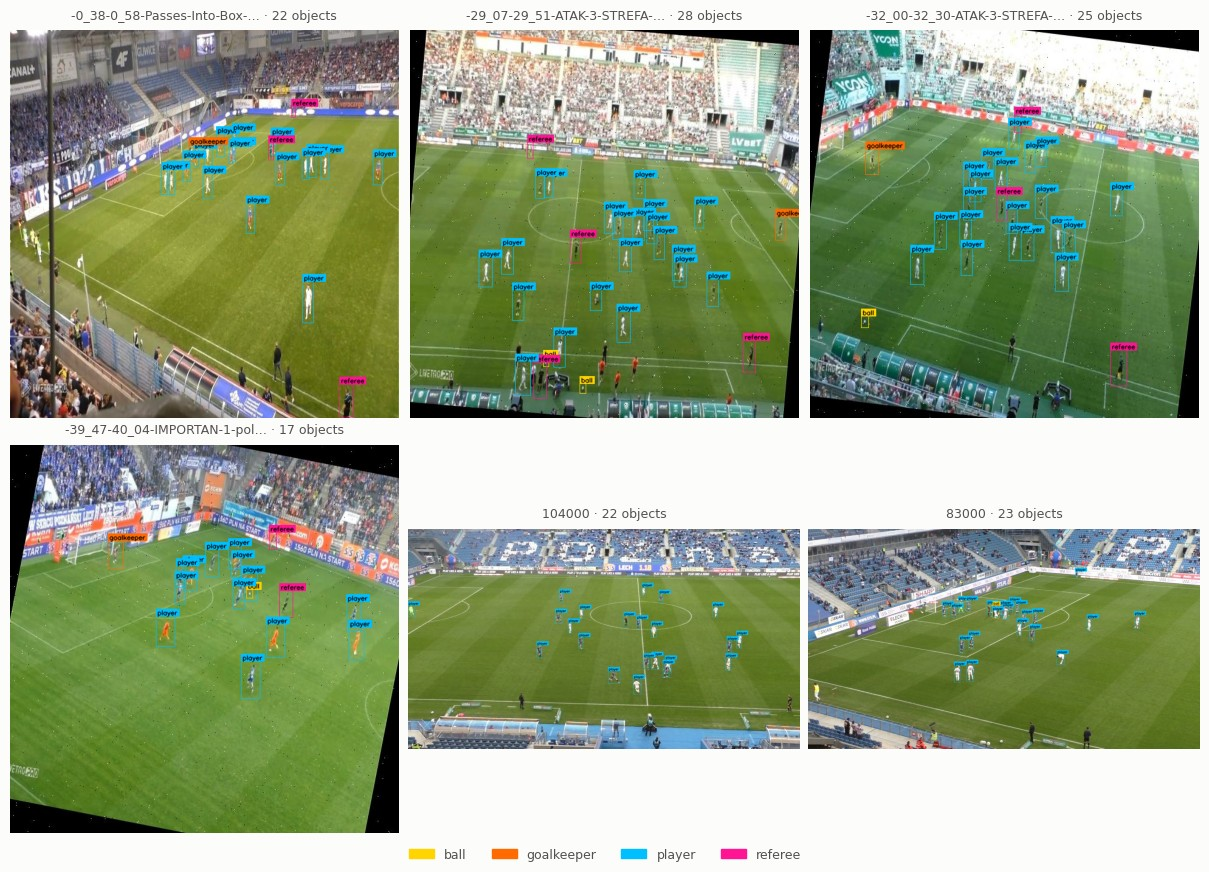

In [3]:
tv.viz.show_samples(detection, "train", n=6)

The pitch dataset is a pose task. Each image has one `pitch` object with 32
landmark keypoints, and `flip_idx` says which landmarks swap places when an
image is mirrored.

Dataset(name='keypoints', task=pose, classes=['pitch'], keypoints=32, train=255, valid=34, test=28)


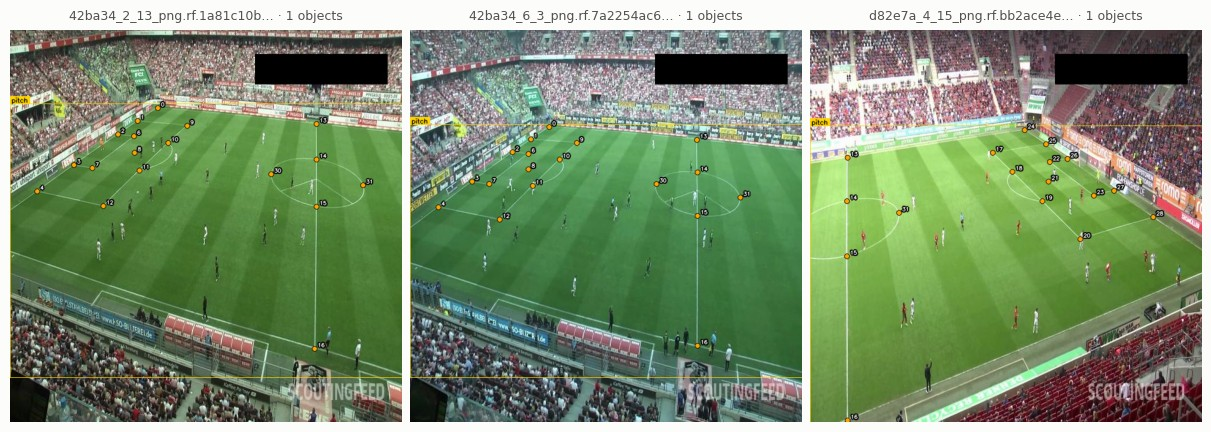

In [4]:
pitch_data = tv.load_dataset(DATA / "keypoints")
print(pitch_data)
tv.viz.show_samples(pitch_data, "train", n=3)

Subsets, re-splits and merges are one call each. `to_yolo` / `to_coco` write
whichever format a trainer needs (images are symlinked, labels rewritten), so
format conversion never has to be done by hand. The trainers call them for you.

In [5]:
train_set = detection.subset({"train": 300, "valid": 60}, seed=0) if QUICK else detection
coco_root = train_set.to_coco(OUT / "datasets" / "football_coco")
print(tv.load_dataset(coco_root))

Dataset(name='football_coco', task=detect, classes=['ball', 'goalkeeper', 'player', 'referee'], train=300, valid=60)


`VideoReader` reads frames in order or by index, and `extract_frames` saves
every n-th frame to disk, for example to annotate a new dataset.

broadcast_60s.mp4: 1920x1080, 25 fps, 60 s


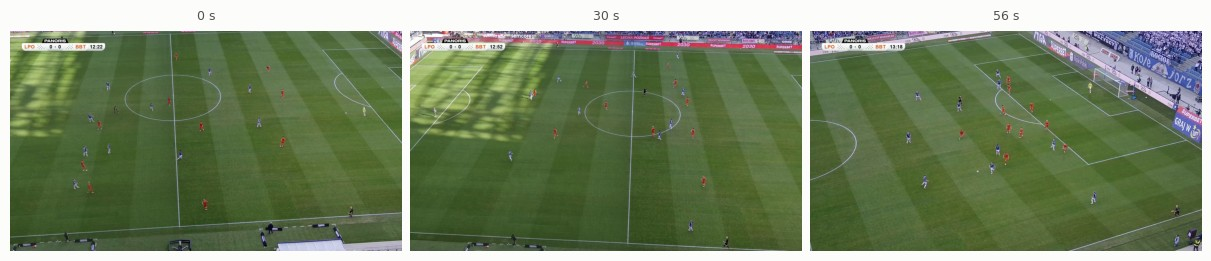

In [6]:
video = tv.VideoReader(VIDEO)
print(f"{VIDEO.name}: {video.width}x{video.height}, {video.fps:.0f} fps, {video.duration:.0f} s")
frames = tv.data.extract_frames(VIDEO, OUT / "frames", every=375, max_frames=4)
tv.show([video.read(i) for i in (0, 750, 1400)], titles=["0 s", "30 s", "56 s"])

StatsBomb 360 event data comes as one row per player visible in an event's
freeze frame, in StatsBomb's 120 x 80 pitch units. `tv.viz.draw_pitch` takes
any pitch size, so a freeze frame can be checked at a glance.

{'period': 1, 'minute': 35, 'second': 35, 'type_name': 'Pass', 'team_name': 'Zagłębie Lubin'}


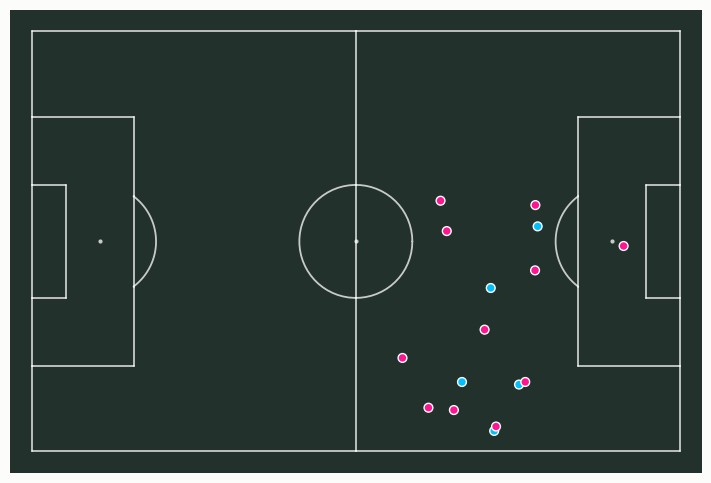

In [7]:
import numpy as np

statsbomb = tv.data.load_statsbomb(DATA / "statsbomb")
event = statsbomb[statsbomb["event_uuid"] == statsbomb["event_uuid"].iloc[0]]
print(event[["period", "minute", "second", "type_name", "team_name"]].iloc[0].to_dict())

fig = tv.viz.draw_pitch(pitch=tv.SoccerPitch(120, 80), size=7)
xy = np.array(event["pitch_location"].tolist())
fig.axes[0].scatter(xy[:, 0], xy[:, 1], s=40, zorder=3, edgecolor="white",
                    c=np.where(event["teammate"], "#00BFFF", "#FF1493"))
fig

## 2. Data augmentation

Transforms take and return `(image, annotations)`, so boxes and keypoints move
with the pixels. `HorizontalFlip` renumbers pitch landmarks with the dataset's
`flip_idx`. Validation data is never augmented.

In [8]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomAffine(degrees=3, translate=0.05, scale=(0.8, 1.2), p=0.7),
    A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.3, p=0.8),
    A.OneOf([A.MotionBlur(), A.GaussianBlur(), A.GaussianNoise()], p=0.4),
    A.JpegCompression(p=0.3),
])
transform

Compose([
    HorizontalFlip(p=0.5),
    RandomAffine(degrees=3.0, translate=0.05, scale=(0.8, 1.2), min_area_ratio=0.3, border_value=(114, 114, 114), p=0.7),
    ColorJitter(brightness=0.25, contrast=0.25, saturation=0.3, hue=0.02, p=0.8),
    OneOf([
        MotionBlur(kernel_size=(3, 11), p=0.5),
        GaussianBlur(sigma=(0.1, 1.5), p=0.5),
        GaussianNoise(std=(2.0, 8.0), p=0.5),
    ], p=0.4),
    JpegCompression(quality=(40, 90), p=0.3),
], p=1.0)

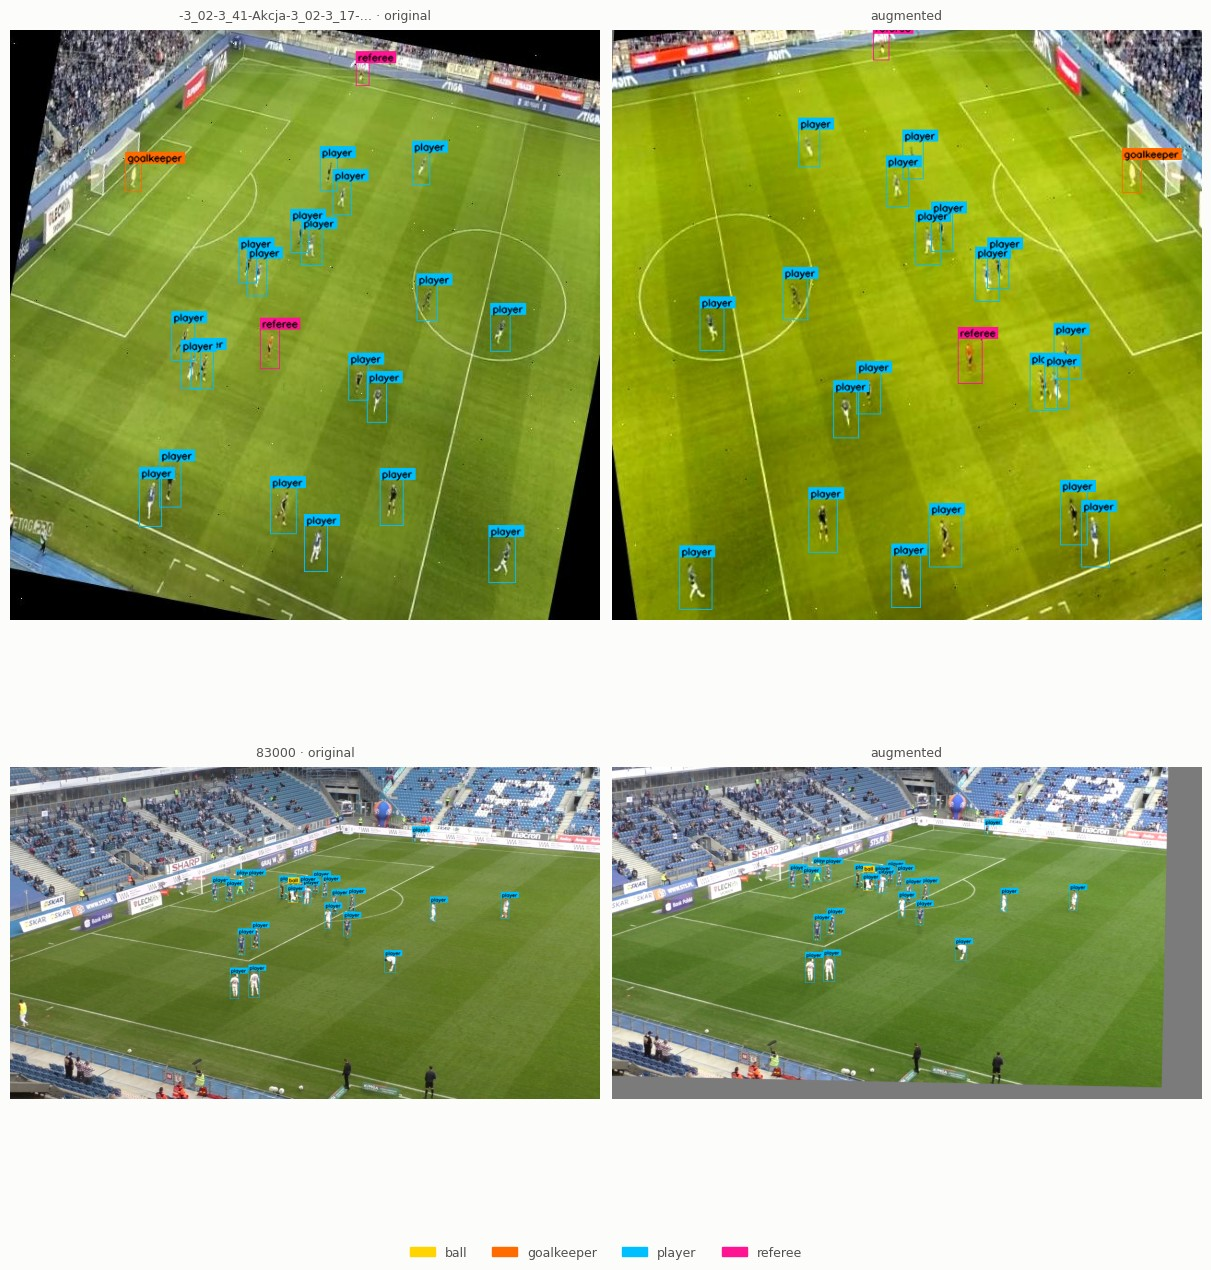

In [9]:
tv.viz.show_augmentations(train_set, transform, n=2)

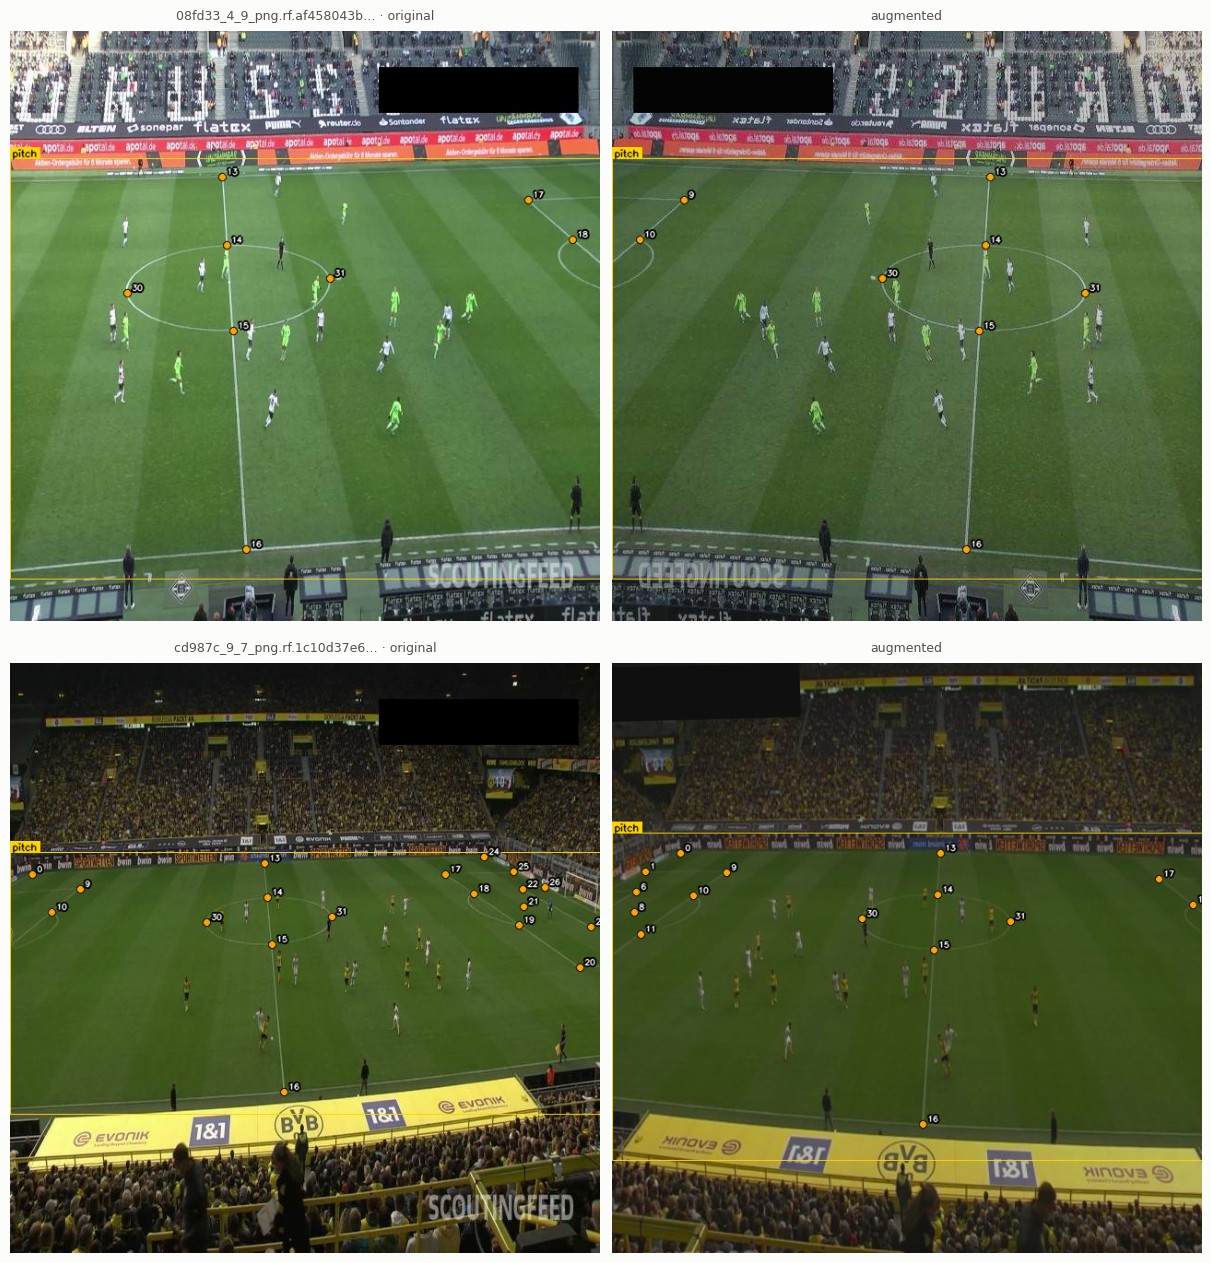

In [10]:
tv.viz.show_augmentations(pitch_data, transform, n=2, seed=3)

In [11]:
augmented = A.augment_dataset(train_set, transform, OUT / "augmented", copies=1, seed=0)
augmented.summary()

augment train:   0%|          | 0/300 [00:00<?, ?it/s]

,images,objects,ball,goalkeeper,player,referee
split,,,,,,
train,600,12819,579,346,10968,926
valid,60,1230,65,18,1090,57


## 3. Model training

Every backend implements the same `Model` interface. `tv.train(name, dataset, ...)`
exports the dataset in the format the backend needs, trains, and returns a
`TrainResult` with the best checkpoint, the per-epoch history and the final
validation metrics. Backend-specific options (here `grad_accum_steps` for
RF-DETR) pass straight through.

With `QUICK = True` these are short demo runs. The trained football checkpoints
in `models/` are used for inference below. The trainers print a lot, so
`%%capture` keeps their logs out of the notebook (`yolo_log.show()` prints one);
curves come from `TrainResult.history`.

In [12]:
%%capture yolo_log
yolo_run = tv.train("yolo", augmented, weights="yolo11n.pt", epochs=EPOCHS["yolo"],
                    batch_size=16, output_dir=OUT / "runs", name="yolo11n")

outputs/notebook/runs/yolo11n/weights/best.pt {'precision': 0.7379243529829067, 'recall': 0.536733462095606, 'map50': 0.5396413386522828, 'map50_95': 0.3081910019863049}


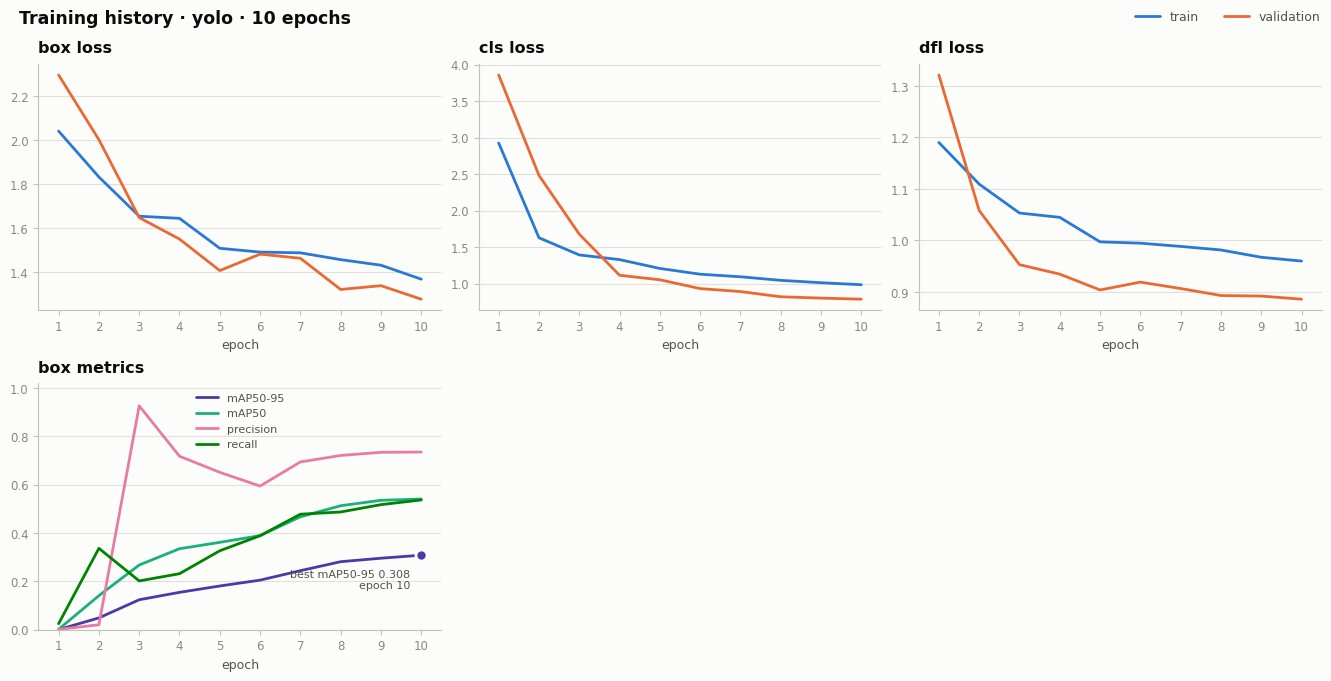

In [13]:
print(yolo_run.weights.relative_to(ROOT), yolo_run.metrics)
tv.viz.plot_training(yolo_run)

In [14]:
%%capture pose_log
pose_run = tv.train("yolo_pose", pitch_data, weights="yolov8n-pose.pt",
                    epochs=EPOCHS["yolo_pose"], batch_size=16, output_dir=OUT / "runs", name="pitch_pose")

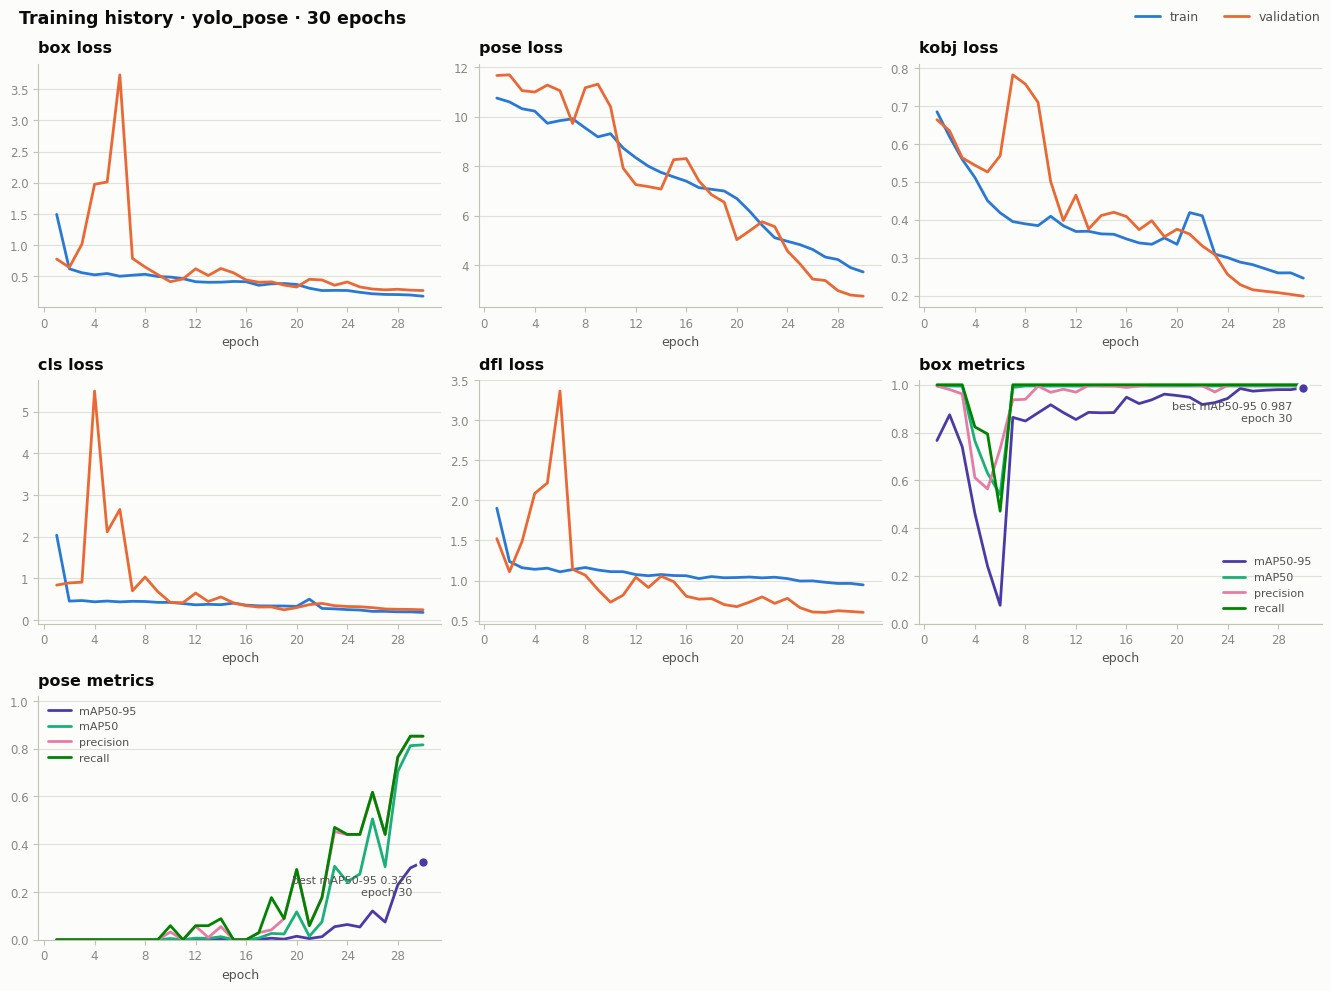

In [15]:
tv.viz.plot_training(pose_run)

In [16]:
%%capture rfdetr_log
rfdetr_run = tv.train("rfdetr", augmented, epochs=EPOCHS["rfdetr"],  # weights=None: COCO-pretrained base
                      batch_size=4, grad_accum_steps=4, output_dir=OUT / "runs", name="rfdetr")

{'map50_95': 0.327942663023406, 'map50': 0.6257663582603828, 'map75': 0.3020002099682952}


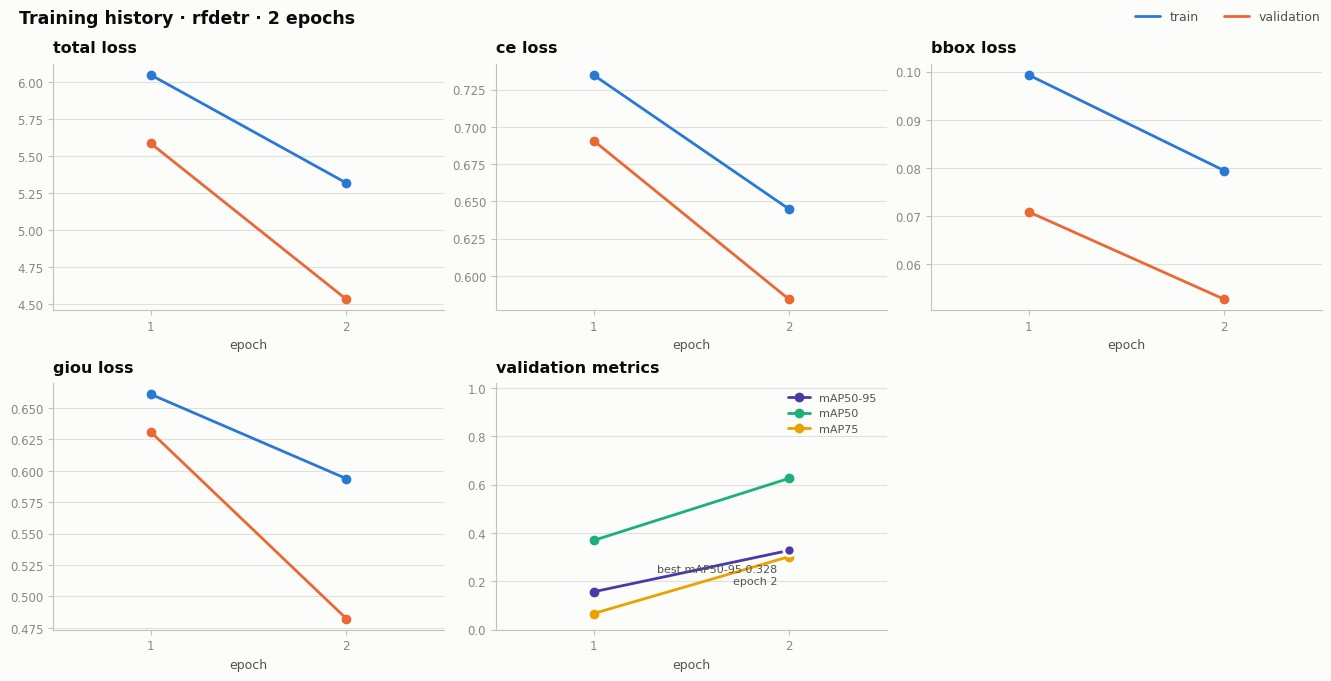

In [17]:
print(rfdetr_run.metrics)
tv.viz.plot_training(rfdetr_run)

## 4. Evaluation

`model.evaluate(dataset)` scores any detector with the same COCO-style code and
matches classes by name, so YOLO and RF-DETR numbers are directly comparable.
Pitch models get pixel error and PCK.

In [18]:
detectors = {
    "YOLO11n (demo run)": yolo_run.load(),
    "RF-DETR (demo run)": rfdetr_run.load(),
    "YOLO11m (football)": tv.load_model("yolo", MODELS / "football_yolo11m.pt"),
    "RF-DETR base (football)": tv.load_model("rfdetr", MODELS / "football_rfdetr_base.pth"),
}
detection_metrics = {name: model.evaluate(detection) for name, model in detectors.items()}
pd.DataFrame({name: m.as_dict() for name, m in detection_metrics.items()}).T.round(3)

Loading pretrain weights


Loading pretrain weights


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


,map50_95,map50,map75
YOLO11n (demo run),0.248,0.442,0.254
RF-DETR (demo run),0.307,0.603,0.258
YOLO11m (football),0.452,0.782,0.465
RF-DETR base (football),0.455,0.833,0.448


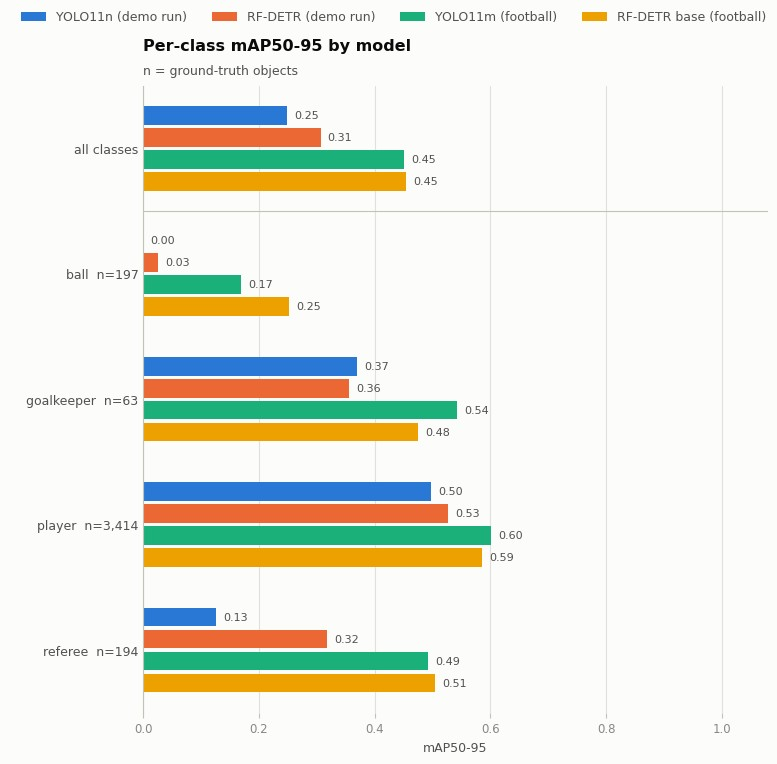

In [19]:
tv.viz.plot_metrics(detection_metrics)

In [20]:
pitch_metrics = {
    "YOLOv8n-pose (demo run)": pose_run.load().evaluate(pitch_data),
    "YOLOv8n-pose (football)": tv.load_model("yolo_pose", MODELS / "pitch_yolov8n_pose.pt").evaluate(pitch_data),
}
pd.DataFrame({name: m.as_dict() for name, m in pitch_metrics.items()}).T.round(3)

,mean_error_px,pck,detection_rate
YOLOv8n-pose (demo run),30.575,0.855,1.0
YOLOv8n-pose (football),8.442,0.998,1.0


## 5. Inference

A model is a callable. It takes a frame and returns `sv.Detections` (with
`class_name`) or `sv.KeyPoints`. Pitch keypoints give a homography that maps pixels to pitch
metres.

In [21]:
import supervision as sv

detector = tv.load_model("yolo", MODELS / "football_yolo11m.pt", conf=0.3)
pitch_model = tv.load_model("yolo_pose", MODELS / "pitch_yolov8n_pose.pt")

frame = video.read(250)
detections = detector(frame)
keypoints = pitch_model(frame)
homography = tv.pitch.HomographyEstimator().update(keypoints)
feet = detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
print(len(detections), "objects:", pd.Series(detections.data["class_name"]).value_counts().to_dict())
print("pitch keypoints:", keypoints.xy.shape)
pd.DataFrame(tv.pitch.frame_to_pitch(feet, homography).astype(float), columns=["x (m)", "y (m)"]).head().round(1)

22 objects: {'player': 22}
pitch keypoints: (1, 32, 2)


,x (m),y (m)
0,46.7,53.2
1,34.4,22.6
2,45.6,34.8
3,53.8,28.5
4,50.3,21.8


`tv.Pipeline` chains detection, tracking (ByteTrack or SAM2), pitch projection
and team classification. Teams are clustered from SigLIP embeddings of player
crops and assigned per track by majority vote, so a player keeps one team for
the whole clip.

In [22]:
pipeline = tv.Pipeline(
    detector=detector,
    keypoint_model=pitch_model,
    tracker="bytetrack",
    team_classifier=tv.teams.TeamClassifier(embedder="siglip"),
)
result = pipeline.run(VIDEO, max_frames=375)  # the first 15 seconds
print(len(result), "frames,", len(result.track_ids), "tracks")
result.to_dataframe().head()

Pipeline:   0%|          | 0/375 [00:00<?, ?frame/s]

375 frames, 41 tracks


,frame,time,object,track_id,class_name,team_id,confidence,x1,y1,x2,y2,pitch_x,pitch_y
0,0,0.0,person,1,player,0,0.837402,1167.532104,262.105591,1181.763672,306.801544,65.860695,36.484665
1,0,0.0,person,2,player,0,0.820818,507.820129,362.145264,531.683899,411.203613,43.517876,41.029610
2,0,0.0,person,3,player,0,0.819549,356.377350,564.270386,381.926788,618.030518,40.897167,52.556580
3,0,0.0,person,4,player,1,0.816118,1327.150391,288.900574,1344.192505,333.207520,70.983147,39.493446
4,0,0.0,person,5,player,1,0.812810,1322.293579,519.817566,1347.726807,571.203003,67.074409,54.236786


In [23]:
result.save(OUT / "result.pkl")
result.to_csv(OUT / "tracks.csv")
freeze_frames = result.to_freeze_frames(period=1)  # StatsBomb-360-like table
freeze_frames[["frame_id", "minute", "second", "player_id", "type", "team_id", "location"]].head()

,frame_id,minute,second,player_id,type,team_id,location
0,0,0,0,1,player,0,"[65.8606948852539, 36.48466491699219]"
1,0,0,0,2,player,0,"[43.51787567138672, 41.02960968017578]"
2,0,0,0,3,player,0,"[40.89716720581055, 52.55657958984375]"
3,0,0,0,4,player,1,"[70.98314666748047, 39.493446350097656]"
4,0,0,0,5,player,1,"[67.07440948486328, 54.236785888671875]"


Components are chosen by name, so the same pipeline can come from YAML and swap
backends. Here RF-DETR replaces YOLO:

In [24]:
config = tv.config.load_config(ROOT / "configs" / "pipeline.yaml")
config.detector = tv.config.ModelConfig(type="rfdetr", weights=MODELS / "football_rfdetr_base.pth", conf=0.5)
rfdetr_result = config.build().run(VIDEO, max_frames=125)
print(len(rfdetr_result), "frames,", len(rfdetr_result.track_ids), "tracks")

Loading pretrain weights


Pipeline:   0%|          | 0/125 [00:00<?, ?frame/s]

Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


125 frames, 25 tracks


## 6. Results visualisation

OpenCV drawing for frames and video, matplotlib for analysis plots. Colours
follow the team ids from the pipeline.

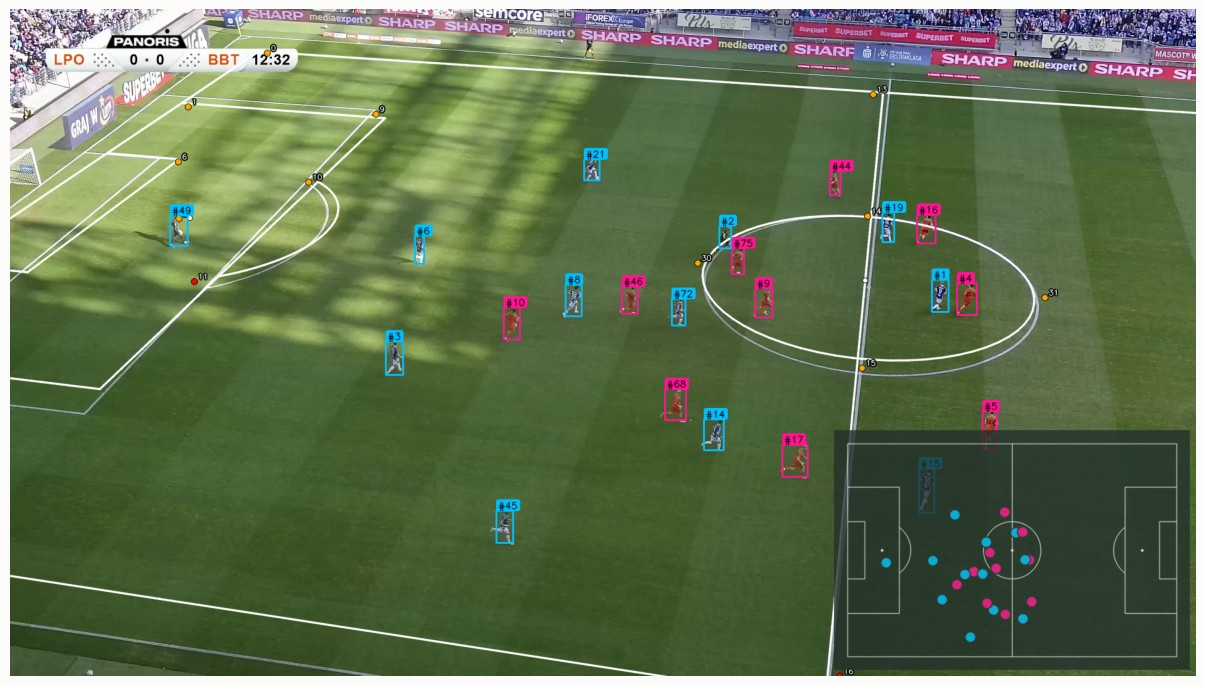

In [25]:
frame_result = result[250]
frame = video.read(frame_result.index)
annotated = tv.viz.FrameAnnotator().annotate(frame, frame_result)
radar = tv.viz.PitchRadar().draw(frame_result)
tv.show(tv.viz.overlay(annotated, radar, position="bottom-right", width_fraction=0.3))

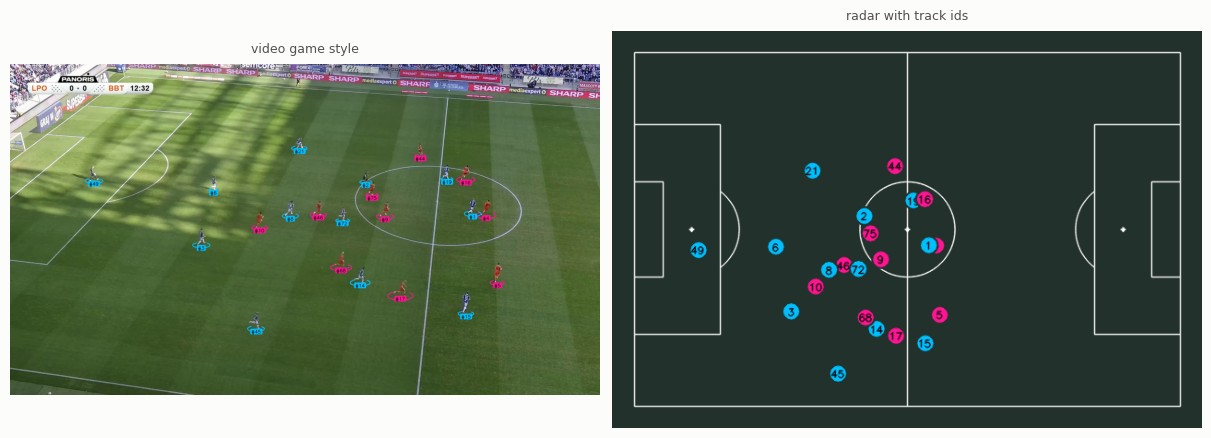

In [26]:
game_style = tv.viz.FrameAnnotator(style="video_game", draw_keypoints=False, draw_pitch_lines=False)
tv.show([game_style.annotate(frame, frame_result), tv.viz.PitchRadar(draw_ids=True).draw(frame_result)],
        titles=["video game style", "radar with track ids"], cols=2)

In [27]:
video_path = tv.viz.render_video(result, VIDEO, OUT / "annotated.mp4", progress=False)
print(video_path.relative_to(ROOT))

outputs/notebook/annotated.mp4


OpenCV writes MPEG-4 Part 2, which browsers don't play; with `ffmpeg` installed
the next cell re-encodes to H.264 and embeds a player.

In [28]:
import shutil
import subprocess

from IPython.display import Video

if shutil.which("ffmpeg"):
    web_video = video_path.with_name("annotated_h264.mp4")
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", str(video_path), "-vf", "scale=960:-2",
                    "-c:v", "libx264", "-pix_fmt", "yuv420p", str(web_video)], check=True)
    display(Video(str(web_video.relative_to(Path.cwd(), walk_up=True)), width=960))
else:
    print("ffmpeg not found; open", video_path, "in a video player")

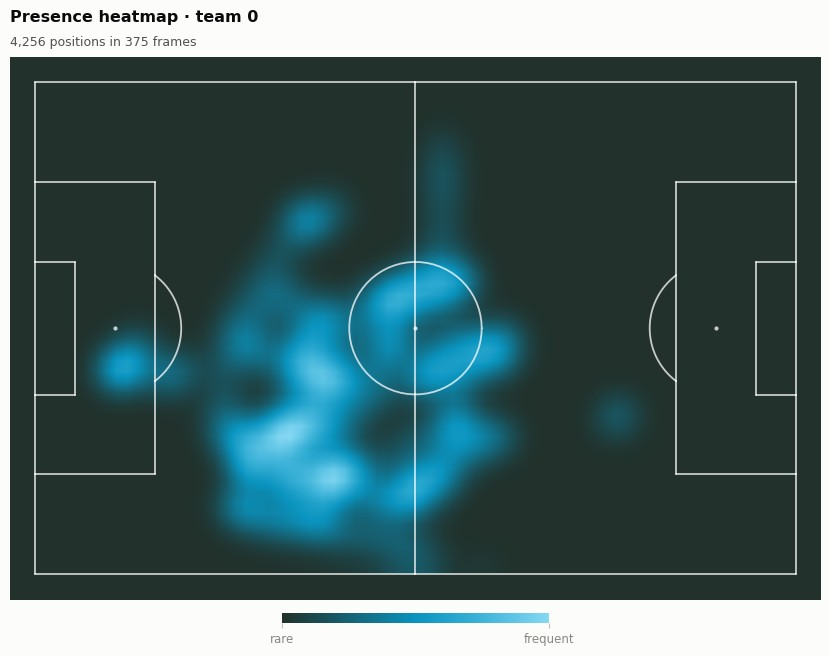

In [29]:
tv.viz.plot_heatmap(result, team=0)

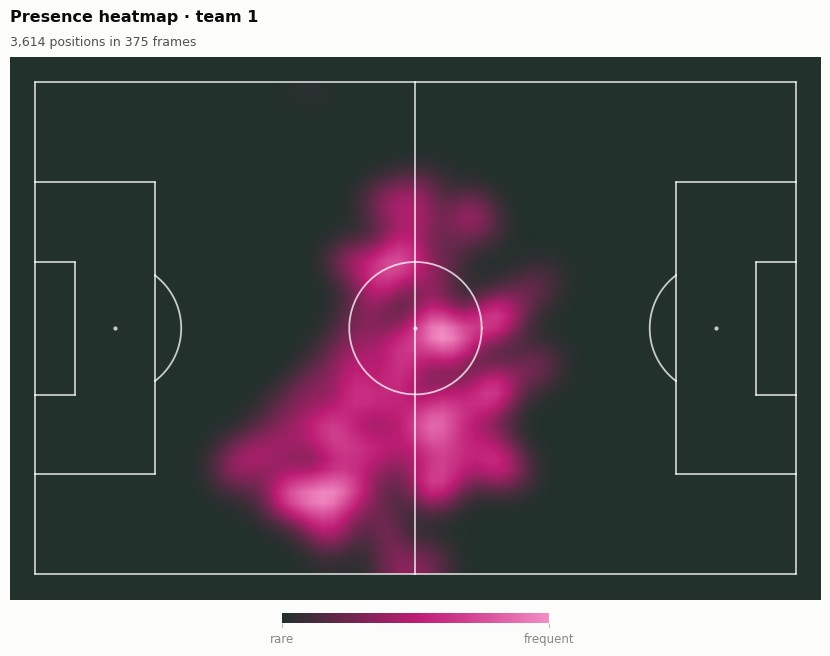

In [30]:
tv.viz.plot_heatmap(result, team=1)

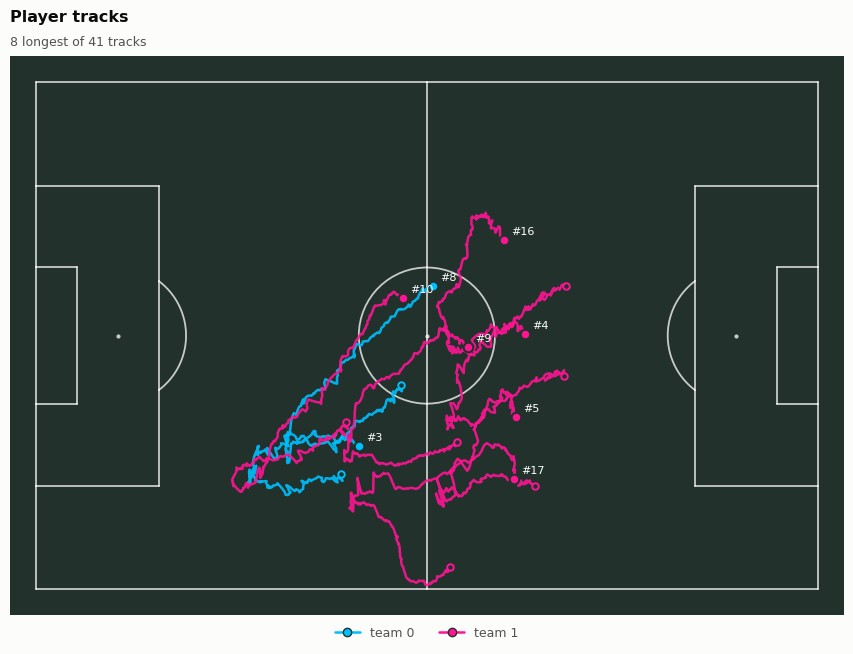

In [31]:
tv.viz.plot_tracks(result, max_tracks=8)

## Where to go from here

* Set `QUICK = False` to train on the full datasets, or run the same step from the shell:
  `tactifoot train yolo --data data/datasets/football_yolo --weights yolo11n.pt --epochs 100`.
* `tactifoot run --config configs/pipeline.yaml --video <match.mp4> --output-dir outputs/<match>`
  processes a whole match and writes tracks, freeze frames and the annotated video.
* `configs/pipeline_rfdetr_sam2.yaml` switches to RF-DETR detections with SAM2 mask
  tracking (needs `uv sync --extra sam2` and the SAM2 repository in `external/`).
* `tv.evaluation.compare_with_statsbomb(result, statsbomb, period=1)` measures
  positional error against StatsBomb 360 data when the video covers the same
  match. Build the pipeline with `pitch=tv.SoccerPitch(120, 80)` so both use
  StatsBomb units, and plot the errors with `tv.viz.plot_distance_histogram`.